### Testing space for uMux model

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from uMux_modeling.include.model import *

In [2]:
a, tau, fr, Qr, Qc, phi0 = 7.062634559012143, 3.849018819916618e-08, 5607703137.28751, 15871.219142919343, 17745.428839278928, -6.404830215540598
res_params = [a, tau, fr, Qr, Qc, phi0]



In [3]:
VNA = VNA_Simulator(z0 = 50)

term = Terminator(VNA.z0)
cap = Capacitor(0.5e-12)
ind = Inductor(2e-9)
res = Resonator(res_params)

channel = Channel()
channel.add(cap)
channel.add(res)
channel.add(ind)

VNA.add(channel,'shunt')


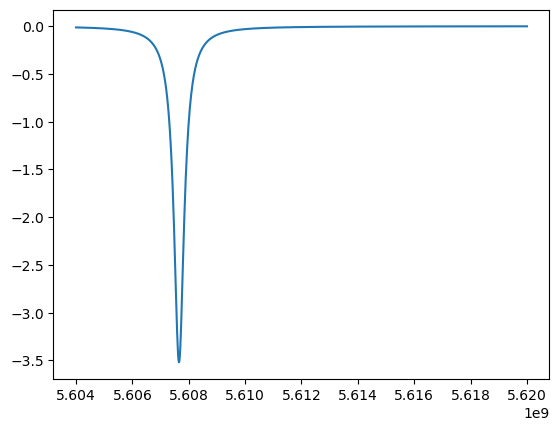

In [10]:
freqs = np.linspace(5.604e9,5.62e9, 1000)
S = VNA.get_s_matrix(freqs)

plt.plot(freqs, 20*np.log10(S[1,0]))


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

def simulate_centered_umux():
    # 1. Setup Target Constants
    f_target = 5.0e9  # 5 GHz
    Phi0 = 2.067e-15
    freqs = np.linspace(f_target - 100e6, f_target + 100e6, 1000)

    # 2. Define Base Inductance
    L_base = 2.0e-9  # 2 nH
    
    # 3. Calculate exact C needed to center at 5GHz
    # C = 1 / ((2 * pi * f)^2 * L)
    C_tuned = 1 / ((2 * np.pi * f_target)**2 * L_base)

    def update_plot(phi_ratio):
        phi_ext = phi_ratio * Phi0
        
        # SQUID and Screened Inductor logic
        # We use a smaller M so the shift isn't so violent it leaves the screen
        squid = SQUID(I_c=2e-6, L_loop=100e-12, phi_ext=phi_ext)
        primary_L = Inductor(L=L_base)
        tuned_L = ScreenedInductor(primary_inductor=primary_L, screening_device=squid, M=80e-12)
        
        # Resonator Channel (Shunt)
        res_channel = Channel(name="Centered_uMux")
        res_channel.add(tuned_L)
        res_channel.add(Capacitor(C=C_tuned))
        
        # VNA Simulation
        vna = VNA_Simulator(z0=50)
        vna.add(res_channel, mode='shunt')
        
        s_params = vna.get_s_matrix(freqs)
        s21_mag = 20 * np.log10(np.abs(s_params[1, 0, :]))

        # Plotting
        plt.figure(figsize=(10, 5))
        plt.plot(freqs / 1e9, s21_mag, color='mediumblue', lw=2)
        plt.axvline(f_target / 1e9, color='red', linestyle='--', alpha=0.5, label='5.0 GHz Target')
        plt.ylim(-70, 1)
        plt.title(f"uMux Notch Centered at 5GHz (Flux: {phi_ratio:.2f} $\Phi_0$)")
        plt.xlabel("Frequency (GHz)")
        plt.ylabel("$|S_{21}|$ (dB)")
        plt.legend()
        plt.grid(True, alpha=0.2)
        plt.show()

    interact(update_plot, phi_ratio=FloatSlider(min=0, max=10, step=0.1, value=0))

simulate_centered_umux()

interactive(children=(FloatSlider(value=0.0, description='phi_ratio', max=10.0, step=0.01), Output()), _dom_cl…